# 05 · Análisis de lenguaje

## 1. Tokenización

Esta sección separa los resúmenes en palabras y números para preparar las representaciones de texto. Parte de las copias limpias del notebook 01 y conserva los identificadores, el texto y las puntuaciones. La misma regla se aplica a los textos de origen para permitir comparaciones posteriores.

La tokenización convierte el texto a minúsculas y unifica las formas Unicode equivalentes. Conserva las contracciones y los posesivos con apóstrofo dentro de una palabra, como don't y student's. Separa las palabras con guion, elimina la puntuación que sirve de separador y conserva los números. Un decimal queda separado por el punto. Esta regla sencilla no distingue todos los usos lingüísticos de los apóstrofos.

No se eliminan palabras frecuentes, no se corrige la ortografía y no se reducen palabras a su raíz. Así se conserva el orden de las palabras y las negaciones para las siguientes técnicas. El texto original se mantiene en una columna aparte. La tokenización usa expresiones regulares y no necesita descargar modelos.

### 1.1. Carga de datos limpios

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / "src").is_dir() and (path / "notebooks").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la raíz del proyecto.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_csv_files

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
for directory in [TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

clean_files = ["summaries_train_clean.csv", "prompts_train_clean.csv"]
if not all((INTERIM_DATA_DIR / name).is_file() for name in clean_files):
    raise FileNotFoundError(
        "Faltan las copias limpias. Ejecute primero 00_data_loading.ipynb "
        "y 01_data_quality.ipynb con los CSV de entrenamiento en data/raw/."
    )
datasets = load_csv_files(INTERIM_DATA_DIR, clean_files)
summaries = datasets["summaries_train_clean"]
prompts = datasets["prompts_train_clean"]
assert not summaries.empty, "No hay resúmenes para analizar."
assert summaries["student_id"].notna().all() and summaries["student_id"].is_unique
assert prompts["prompt_id"].notna().all() and prompts["prompt_id"].is_unique
assert summaries["prompt_id"].notna().all()
assert summaries["prompt_id"].isin(prompts["prompt_id"]).all()
plt.rcParams.update({"figure.figsize": [10, 4], "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

In [2]:
from src.tokenization import tokenize_text

for frame, columns in [(summaries, ["text"]), (prompts, ["prompt_text"])]:
    for column in columns:
        assert frame[column].map(lambda value: isinstance(value, str)).all(), "Hay textos faltantes o no válidos."
        assert frame[column].str.strip().ne("").all(), "Hay textos vacíos."

tokenized_summaries = summaries.copy()
tokenized_prompts = prompts.copy()
tokenized_summaries["tokens"] = summaries["text"].map(tokenize_text)
tokenized_prompts["tokens"] = prompts["prompt_text"].map(tokenize_text)
tokenized_summaries["token_count"] = tokenized_summaries["tokens"].str.len()
tokenized_prompts["token_count"] = tokenized_prompts["tokens"].str.len()

assert tokenized_summaries[summaries.columns].equals(summaries)
assert tokenized_prompts[prompts.columns].equals(prompts)
with pd.option_context("display.max_colwidth", 140):
    display(tokenized_summaries[["student_id", "text", "tokens", "token_count"]].head())
    display(tokenized_prompts[["prompt_id", "prompt_title", "token_count"]])

,student_id,text,tokens,token_count
0,000e8c3c7ddb,The third wave was an experimentto see how people reacted to a new one leader government. It gained popularity as people wanted to try n...,"[the, third, wave, was, an, experimentto, see, how, people, reacted, to, a, new, one, leader, government, it, gained, popularity, as, pe...",61
1,0020ae56ffbf,They would rub it up with soda to make the smell go away and it wouldnt be a bad smell. Some of the meat would be tossed on the floor wh...,"[they, would, rub, it, up, with, soda, to, make, the, smell, go, away, and, it, wouldnt, be, a, bad, smell, some, of, the, meat, would, ...",52
2,004e978e639e,"In Egypt, there were many occupations and social classes involved in day-to-day living. In many instances if you were at the bottom of t...","[in, egypt, there, were, many, occupations, and, social, classes, involved, in, day, to, day, living, in, many, instances, if, you, were...",237
3,005ab0199905,The highest class was Pharaohs these people were gods.Then the 2nd highest class was a gonvener.Chiefs minister were called a vizier as ...,"[the, highest, class, was, pharaohs, these, people, were, gods, then, the, 2nd, highest, class, was, a, gonvener, chiefs, minister, were...",28
4,0070c9e7af47,"The Third Wave developed rapidly because the students genuinly believed that it was the best course of action. Their grades, acomplishm...","[the, third, wave, developed, rapidly, because, the, students, genuinly, believed, that, it, was, the, best, course, of, action, their, ...",203


,prompt_id,prompt_title,token_count
0,39c16e,On Tragedy,600
1,3b9047,Egyptian Social Structure,554
2,814d6b,The Third Wave,598
3,ebad26,Excerpt from The Jungle,976


### 1.2. Revisión de la tokenización

Se compara el conteo de tokens con el conteo por espacios que aparece en el notebook 01. Pueden ser diferentes porque aquí la puntuación separa palabras y los símbolos aislados no cuentan como tokens. No se interpreta esa diferencia como un error.

Se revisan los textos que quedan sin tokens. No se eliminan de forma automática. También se muestra el tamaño del vocabulario como una comprobación de la transformación, sin desarrollar todavía las otras representaciones de lenguaje.

In [3]:
tokenized_summaries["whitespace_word_count"] = summaries["text"].str.split().str.len()
tokenized_summaries["token_count_difference"] = (
    tokenized_summaries["token_count"] - tokenized_summaries["whitespace_word_count"]
)
token_quality = pd.DataFrame([
    {"dataset": name, "textos": len(frame), "tokens_totales": int(frame["token_count"].sum()),
     "vocabulario": len({token for tokens in frame["tokens"] for token in tokens}),
     "sin_tokens": int(frame["token_count"].eq(0).sum())}
    for name, frame in [("summaries", tokenized_summaries), ("prompts", tokenized_prompts)]
])
display(token_quality)
token_quality.to_csv(TABLES_DIR / "05_tokenization_quality.csv", index=False)
token_description = tokenized_summaries[["token_count", "whitespace_word_count", "token_count_difference"]].describe().T
display(token_description.round(2))
token_description.to_csv(TABLES_DIR / "05_tokenization_descriptive.csv", index_label="variable")
different = tokenized_summaries["token_count_difference"].ne(0)
print(f"Hay {different.sum():,} resúmenes con un conteo diferente al basado en espacios.")
with pd.option_context("display.max_colwidth", 140):
    display(tokenized_summaries.loc[different, ["text", "tokens", "token_count", "whitespace_word_count"]].head())
for frame, column in [(tokenized_summaries, "text"), (tokenized_prompts, "prompt_text")]:
    if frame["token_count"].eq(0).any():
        display(frame.loc[frame["token_count"].eq(0), ["prompt_id", column]])

,dataset,textos,tokens_totales,vocabulario,sin_tokens
0,summaries,7165,538507,12469,0
1,prompts,4,2728,949,0


,count,mean,std,min,25%,50%,75%,max
token_count,7165.0,75.16,53.79,25.0,39.0,58.0,92.0,660.0
whitespace_word_count,7165.0,74.81,53.50,22.0,39.0,58.0,92.0,647.0
token_count_difference,7165.0,0.35,1.43,-10.0,0.0,0.0,0.0,22.0


Hay 2,411 resúmenes con un conteo diferente al basado en espacios.


,text,tokens,token_count,whitespace_word_count
2,"In Egypt, there were many occupations and social classes involved in day-to-day living. In many instances if you were at the bottom of t...","[in, egypt, there, were, many, occupations, and, social, classes, involved, in, day, to, day, living, in, many, instances, if, you, were...",237,235
3,The highest class was Pharaohs these people were gods.Then the 2nd highest class was a gonvener.Chiefs minister were called a vizier as ...,"[the, highest, class, was, pharaohs, these, people, were, gods, then, the, 2nd, highest, class, was, a, gonvener, chiefs, minister, were...",28,25
6,The Egyptian society is really different from other socicties I have learned about. As stated in the story in paragraph 6-13 it describe...,"[the, egyptian, society, is, really, different, from, other, socicties, i, have, learned, about, as, stated, in, the, story, in, paragra...",80,78
13,"Aristotle states that an ideal tragedy should have a ""complex plan"" (a well-thought-out plot), ""imitate actions which excite pity and fe...","[aristotle, states, that, an, ideal, tragedy, should, have, a, complex, plan, a, well, thought, out, plot, imitate, actions, which, exci...",54,52
17,They would pickle it in an attempt to keep it fresh. They would insert a hot iron that would burn off parts that had spoiled. They woul...,"[they, would, pickle, it, in, an, attempt, to, keep, it, fresh, they, would, insert, a, hot, iron, that, would, burn, off, parts, that, ...",163,158


### 1.3. Exportación para continuar el análisis

Se guardan los resúmenes y los prompts tokenizados en data/processed como JSON Lines. Este formato mantiene cada lista de tokens como una lista y evita convertirla en texto dentro de un CSV. Los archivos se pueden cargar con pd.read_json usando lines=True. Los tokens de los resúmenes quedan disponibles en tokenized_summaries para continuar este notebook.

Estos archivos son derivados y se regeneran al ejecutar esta sección. No se cambia el contenido de data/raw ni de data/interim. Los nombres de las tablas llevan el prefijo 05_tokenization para distinguirlas de las siguientes secciones.

In [4]:
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
for filename, frame in [
    ("summaries_train_tokenized.jsonl", tokenized_summaries),
    ("prompts_train_tokenized.jsonl", tokenized_prompts),
]:
    path = PROCESSED_DATA_DIR / filename
    frame.to_json(path, orient="records", lines=True, force_ascii=False, double_precision=15)
    restored = pd.read_json(path, orient="records", lines=True, dtype=False, convert_dates=False)
    assert restored["tokens"].tolist() == frame["tokens"].tolist()
    assert restored["prompt_id"].tolist() == frame["prompt_id"].tolist()
    if "student_id" in frame:
        assert restored["student_id"].tolist() == frame["student_id"].tolist()
    print(f"Guardado: data/processed/{filename}, con {len(frame):,} filas.")

Guardado: data/processed/summaries_train_tokenized.jsonl, con 7,165 filas.
Guardado: data/processed/prompts_train_tokenized.jsonl, con 4 filas.


### 1.4. Resultado de la preparación

La tokenización mantiene la relación entre cada resumen, su prompt y sus puntuaciones. Las listas conservan el orden de las palabras y quedan listas para formar secuencias o matrices de texto en las siguientes secciones. Las diferencias frente al conteo por espacios dependen de las reglas usadas y deben considerarse al comparar longitudes con otros notebooks.

In [5]:
summary_quality = token_quality.loc[token_quality["dataset"].eq("summaries")].iloc[0]
print(f"Se prepararon {summary_quality['textos']:,} resúmenes con "
      f"{summary_quality['tokens_totales']:,} tokens y "
      f"{summary_quality['vocabulario']:,} tokens distintos.")
print(f"La mediana es de {tokenized_summaries['token_count'].median():.1f} tokens por resumen.")
print(f"Hay {summary_quality['sin_tokens']:,} resúmenes sin tokens después de aplicar las reglas.")

Se prepararon 7,165 resúmenes con 538,507 tokens y 12,469 tokens distintos.
La mediana es de 58.0 tokens por resumen.
Hay 0 resúmenes sin tokens después de aplicar las reglas.


### Hallazgos de la tokenización

Los 7,165 resúmenes producen 538,507 tokens y un vocabulario de 12,469 tokens distintos. La mediana es de 58 tokens por resumen. Ningún resumen queda sin tokens, por lo que esta transformación permite mantener todas las observaciones.

En 2,411 resúmenes el conteo cambia frente al conteo por espacios del notebook 01. La diferencia es esperable por el tratamiento de signos y separadores. Para las siguientes representaciones conviene usar las mismas listas de tokens y mantener explícita la regla de conteo al comparar longitudes.

Los archivos procesados incluyen también los cuatro textos de origen tokenizados. Las listas conservan el orden de las palabras y quedan disponibles para continuar el análisis de lenguaje.

## 2. Frecuencia de palabras - contribución de Nadissa

### Objetivo
Describir qué palabras aparecen con mayor frecuencia y en cuántos resúmenes, sin construir una matriz Bag of Words. Se reportan frecuencia absoluta, proporción sobre todos los tokens y prevalencia documental. Esta última reduce la ventaja de los textos largos.

Se conservan las stopwords: son parte de la estructura lingüística y eliminarlas cambiaría la interpretación. Las palabras funcionales frecuentes se distinguen de las palabras temáticas mediante su cobertura entre prompts.

,ngram,frecuencia_absoluta,frecuencia_relativa,documentos,prevalencia_documental,prompts_con_palabra
0,the,43484,0.08075,6896,0.96246,4
1,and,20078,0.03728,6299,0.87913,4
2,to,15975,0.02967,5671,0.79149,4
3,of,14653,0.02721,5586,0.77962,4
4,a,11841,0.02199,4807,0.67090,4
5,it,11469,0.02130,4497,0.62763,4
6,in,9253,0.01718,4396,0.61354,4
7,they,8401,0.01560,3576,0.49909,4
8,that,8089,0.01502,4098,0.57195,4
9,was,6784,0.01260,3297,0.46015,4


,ngram,frecuencia_absoluta,frecuencia_relativa,documentos,prevalencia_documental,prompts_con_palabra
13,meat,5320,0.00988,1820,0.25401,1
20,tragedy,3074,0.00571,1567,0.21870,1
29,spoiled,2387,0.00443,1296,0.18088,1
32,good,2339,0.00434,1550,0.21633,4
33,bad,2328,0.00432,1601,0.22345,4
34,people,2273,0.00422,1472,0.20544,4
36,gods,2152,0.00400,1066,0.14878,2
43,slaves,1920,0.00357,1203,0.16790,1
45,social,1855,0.00344,1118,0.15604,3
49,students,1714,0.00318,739,0.10314,2


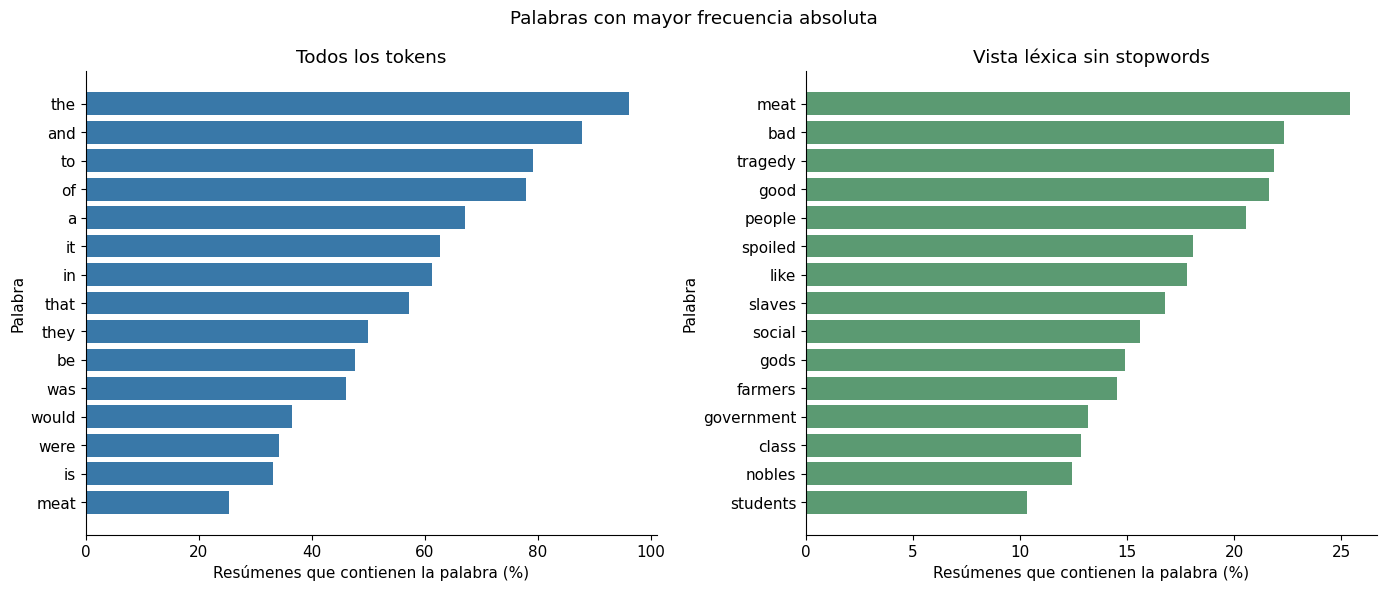

In [6]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from src.ngrams import (
    compare_extreme_group_prevalence,
    ngram_frequency_table,
    performance_groups_by_prompt,
    prompt_ngram_overlap,
)

word_frequency = ngram_frequency_table(tokenized_summaries['tokens'], n=1)
word_by_prompt = []
for prompt_id, group in tokenized_summaries.groupby('prompt_id', sort=True):
    table = ngram_frequency_table(group['tokens'], n=1)
    table.insert(0, 'prompt_id', prompt_id)
    word_by_prompt.append(table)
word_by_prompt = pd.concat(word_by_prompt, ignore_index=True)
prompt_coverage = (word_by_prompt.loc[word_by_prompt['documentos'] > 0]
                   .groupby('ngram')['prompt_id'].nunique().rename('prompts_con_palabra'))
word_frequency = word_frequency.merge(prompt_coverage, on='ngram', how='left')
content_word_frequency = word_frequency.loc[~word_frequency['ngram'].isin(ENGLISH_STOP_WORDS)].copy()
display(word_frequency.head(20).round(5))
display(content_word_frequency.head(20).round(5))
word_frequency.to_csv(TABLES_DIR / '05_word_frequency.csv', index=False)
word_by_prompt.to_csv(TABLES_DIR / '05_word_frequency_by_prompt.csv', index=False)
content_word_frequency.to_csv(TABLES_DIR / '05_content_word_frequency.csv', index=False)

top_words = word_frequency.head(15).sort_values('prevalencia_documental')
top_content_words = content_word_frequency.head(15).sort_values('prevalencia_documental')
fig, axes = plt.subplots(1, 2, figsize=[14, 6])
for ax, table, title, color in [
    (axes[0], top_words, 'Todos los tokens', '#3978a8'),
    (axes[1], top_content_words, 'Vista léxica sin stopwords', '#5b9a72'),
]:
    ax.barh(table['ngram'], 100 * table['prevalencia_documental'], color=color)
    ax.set(title=title, xlabel='Resúmenes que contienen la palabra (%)', ylabel='Palabra')
fig.suptitle('Palabras con mayor frecuencia absoluta')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_word_prevalence_top15.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Bigramas y evaluación de trigramas

Los bigramas son el análisis principal porque añaden contexto sin fragmentar excesivamente el corpus. Los trigramas se diagnostican antes de decidir su alcance: se cuantifican tipos únicos, tipos que aparecen una sola vez y cobertura documental.

,tipo,tipos_unicos,tipos_con_una_ocurrencia,proporcion_tipos_unicos,tipos_en_10_documentos,prevalencia_documental_maxima
0,bigramas,95262,64719,0.6794,6304,0.3740
1,trigramas,216504,175239,0.8094,5565,0.1161


,ngram,frecuencia_absoluta,frecuencia_relativa,documentos,prevalencia_documental
0,of the,4110,0.00774,2680,0.37404
1,in the,3090,0.00582,2208,0.30816
2,they would,2562,0.00482,1454,0.20293
3,at the,2067,0.00389,1205,0.16818
4,the meat,1714,0.00323,1047,0.14613
5,to the,1661,0.00313,1298,0.18116
6,it was,1495,0.00281,1172,0.16357
7,to be,1455,0.00274,1250,0.17446
8,spoiled meat,1449,0.00273,976,0.13622
9,the gods,1254,0.00236,777,0.10844


,ngram,frecuencia_absoluta,frecuencia_relativa,documentos,prevalencia_documental
0,an ideal tragedy,1051,0.00201,832,0.11612
1,the third wave,851,0.00162,689,0.09616
2,at the top,837,0.00160,740,0.10328
3,pity and fear,834,0.00159,742,0.10356
4,with soda to,725,0.00138,658,0.09184
5,take away the,722,0.00138,632,0.08821
6,to take away,712,0.00136,632,0.08821
7,good to bad,705,0.00134,664,0.09267
8,soda to take,692,0.00132,630,0.08793
9,away the smell,653,0.00125,593,0.08276


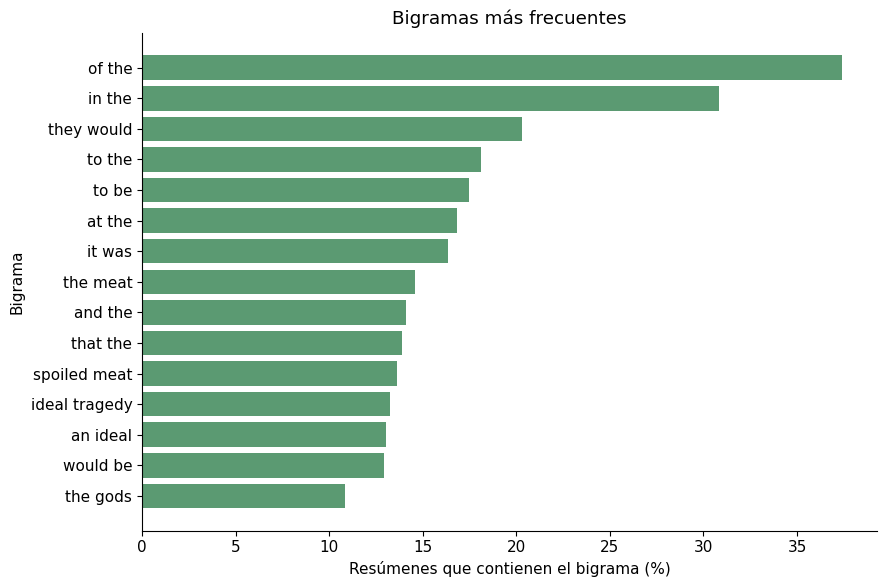

In [7]:
bigram_frequency = ngram_frequency_table(tokenized_summaries['tokens'], n=2)
trigram_frequency = ngram_frequency_table(tokenized_summaries['tokens'], n=3)
bigram_frequency.to_csv(TABLES_DIR / '05_bigram_frequency.csv', index=False)
trigram_frequency.head(1000).to_csv(TABLES_DIR / '05_trigram_frequency_top1000.csv', index=False)
diagnostic_rows = []
for name, table in [('bigramas', bigram_frequency), ('trigramas', trigram_frequency)]:
    diagnostic_rows.append({
        'tipo': name, 'tipos_unicos': len(table),
        'tipos_con_una_ocurrencia': int(table['frecuencia_absoluta'].eq(1).sum()),
        'proporcion_tipos_unicos': table['frecuencia_absoluta'].eq(1).mean(),
        'tipos_en_10_documentos': int(table['documentos'].ge(10).sum()),
        'prevalencia_documental_maxima': table['prevalencia_documental'].max(),
    })
ngram_diagnostic = pd.DataFrame(diagnostic_rows)
display(ngram_diagnostic.round(4))
display(bigram_frequency.head(20).round(5))
display(trigram_frequency.head(20).round(5))
ngram_diagnostic.to_csv(TABLES_DIR / '05_ngram_sparsity_diagnostic.csv', index=False)

top_bigrams = bigram_frequency.head(15).sort_values('prevalencia_documental')
fig, ax = plt.subplots(figsize=[9, 6])
ax.barh(top_bigrams['ngram'], 100 * top_bigrams['prevalencia_documental'], color='#5b9a72')
ax.set(title='Bigramas más frecuentes', xlabel='Resúmenes que contienen el bigrama (%)', ylabel='Bigrama')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_bigram_prevalence_top15.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Palabras y bigramas por nivel de desempeño

### Procedimiento
Para cada objetivo se calculan terciles dentro de cada prompt. Así, `bajo`, `medio` y `alto` representan posiciones relativas frente a estudiantes que respondieron al mismo texto fuente. Los límites no son arbitrarios: corresponden a los percentiles 33.3 y 66.7 observados.

La comparación usa como criterio principal la frecuencia relativa por resumen, de modo que cada documento aporte una proporción y no una cantidad favorecida por su longitud. La prevalencia documental se conserva como evidencia complementaria. Las diferencias se calculan dentro de cada prompt y luego se promedian, dando el mismo peso a cada tema. Para interpretar patrones compartidos se exigen apariciones en al menos dos prompts. Las etiquetas sólo forman grupos exploratorios; no se incorporan a una característica predictiva.

,objetivo,unidad,candidatos,presentes_en_2_o_mas_prompts
0,content,palabras,1480,1008


,ngram,prevalencia_baja,prevalencia_alta,frecuencia_relativa_baja,frecuencia_relativa_alta,diferencia_frecuencia_relativa,prompts_con_ngram,patron
0,complex,0.09866,0.11682,0.00301,0.00168,-0.00133,3,Mayor en nivel bajo
1,like,0.12450,0.22902,0.00372,0.00243,-0.00129,4,Mayor en nivel bajo
2,kids,0.05036,0.04305,0.00180,0.00070,-0.00109,4,Mayor en nivel bajo
3,people,0.16319,0.32622,0.00560,0.00453,-0.00106,4,Mayor en nivel bajo
4,good,0.14770,0.25423,0.00522,0.00430,-0.00091,4,Mayor en nivel bajo
5,time,0.08871,0.15138,0.00234,0.00149,-0.00085,4,Mayor en nivel bajo
6,got,0.05406,0.07228,0.00159,0.00076,-0.00083,4,Mayor en nivel bajo
7,change,0.06191,0.10154,0.00194,0.00132,-0.00063,4,Mayor en nivel bajo
8,states,0.02723,0.16226,0.00065,0.00174,0.00109,4,Mayor en nivel alto
9,paragraph,0.04903,0.16201,0.00141,0.00222,0.00081,4,Mayor en nivel alto


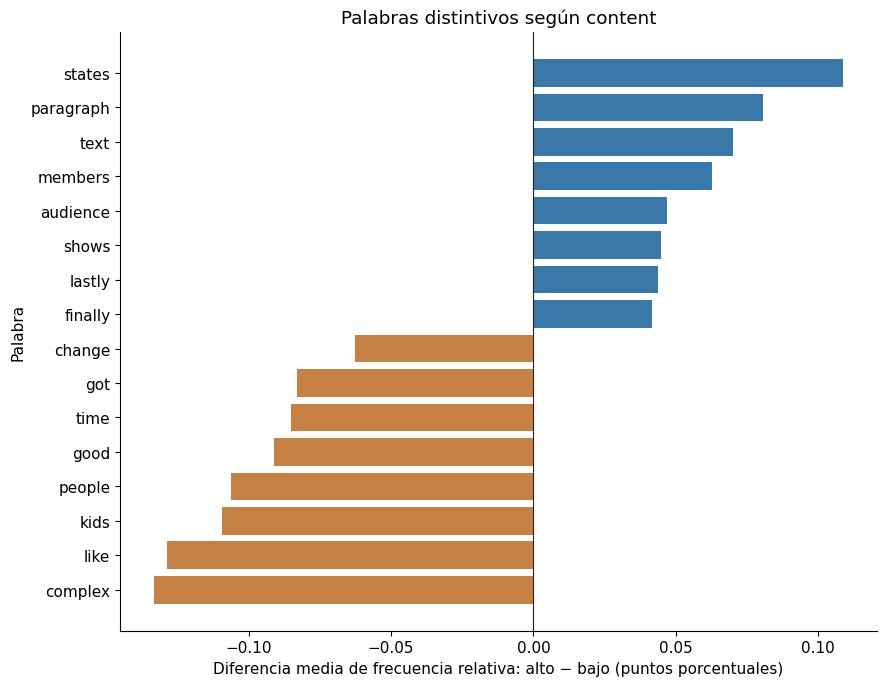

,objetivo,unidad,candidatos,presentes_en_2_o_mas_prompts
0,content,bigramas,6304,2743


,ngram,prevalencia_baja,prevalencia_alta,frecuencia_relativa_baja,frecuencia_relativa_alta,diferencia_frecuencia_relativa,prompts_con_ngram,patron
0,be used,0.03075,0.04699,0.00082,0.00038,-0.00044,3,Mayor en nivel bajo
1,like a,0.04194,0.07807,0.00119,0.00076,-0.00043,4,Mayor en nivel bajo
2,good to,0.05930,0.11341,0.00184,0.00142,-0.00042,3,Mayor en nivel bajo
3,other people,0.01476,0.01311,0.00040,0.00013,-0.00027,4,Mayor en nivel bajo
4,a lot,0.01948,0.03020,0.00050,0.00024,-0.00027,4,Mayor en nivel bajo
5,lot of,0.01749,0.02664,0.00047,0.00021,-0.00026,4,Mayor en nivel bajo
6,i think,0.01129,0.00612,0.00030,0.00006,-0.00024,4,Mayor en nivel bajo
7,make it,0.02446,0.05086,0.00066,0.00047,-0.00019,4,Mayor en nivel bajo
8,the text,0.02923,0.13551,0.00067,0.00144,0.00076,4,Mayor en nivel alto
9,it states,0.01184,0.07075,0.00026,0.00068,0.00042,4,Mayor en nivel alto


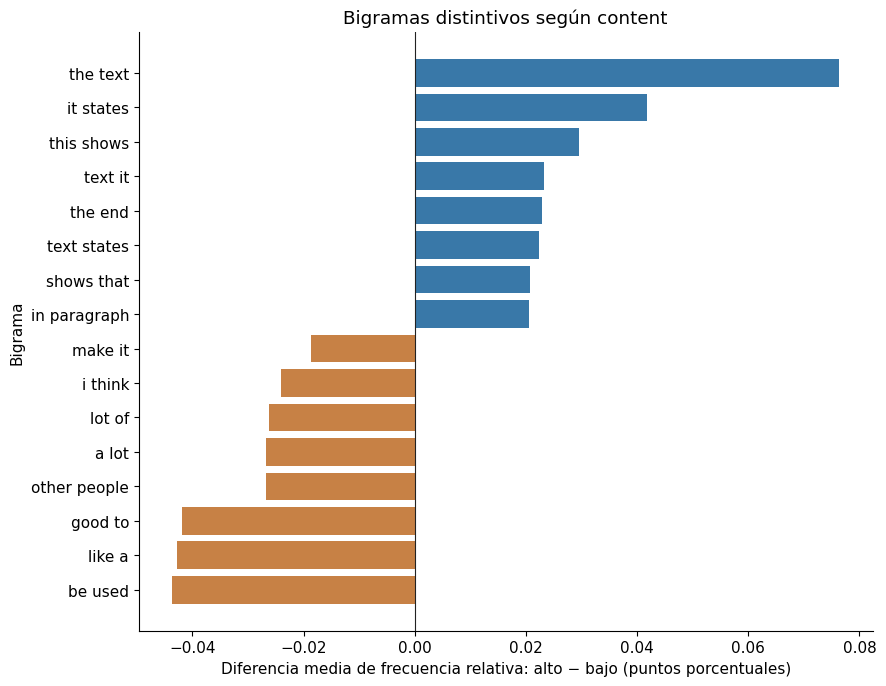

,objetivo,unidad,candidatos,presentes_en_2_o_mas_prompts
0,wording,palabras,1480,1002


,ngram,prevalencia_baja,prevalencia_alta,frecuencia_relativa_baja,frecuencia_relativa_alta,diferencia_frecuencia_relativa,prompts_con_ngram,patron
0,kids,0.04449,0.04048,0.00158,0.00078,-0.00081,4,Mayor en nivel bajo
1,good,0.15481,0.23419,0.00509,0.00438,-0.00071,4,Mayor en nivel bajo
2,single,0.04560,0.05159,0.00108,0.00059,-0.00049,4,Mayor en nivel bajo
3,brought,0.03583,0.04225,0.00081,0.00043,-0.00038,4,Mayor en nivel bajo
4,hand,0.04568,0.06580,0.00110,0.00071,-0.00038,4,Mayor en nivel bajo
5,social,0.11327,0.17019,0.00331,0.00308,-0.00023,3,Mayor en nivel bajo
6,taken,0.03682,0.05102,0.00062,0.00042,-0.00021,4,Mayor en nivel bajo
7,telling,0.00892,0.01016,0.00027,0.00009,-0.00018,4,Mayor en nivel bajo
8,class,0.08658,0.20125,0.00248,0.00337,0.00089,3,Mayor en nivel alto
9,audience,0.02256,0.08136,0.00066,0.00135,0.00069,3,Mayor en nivel alto


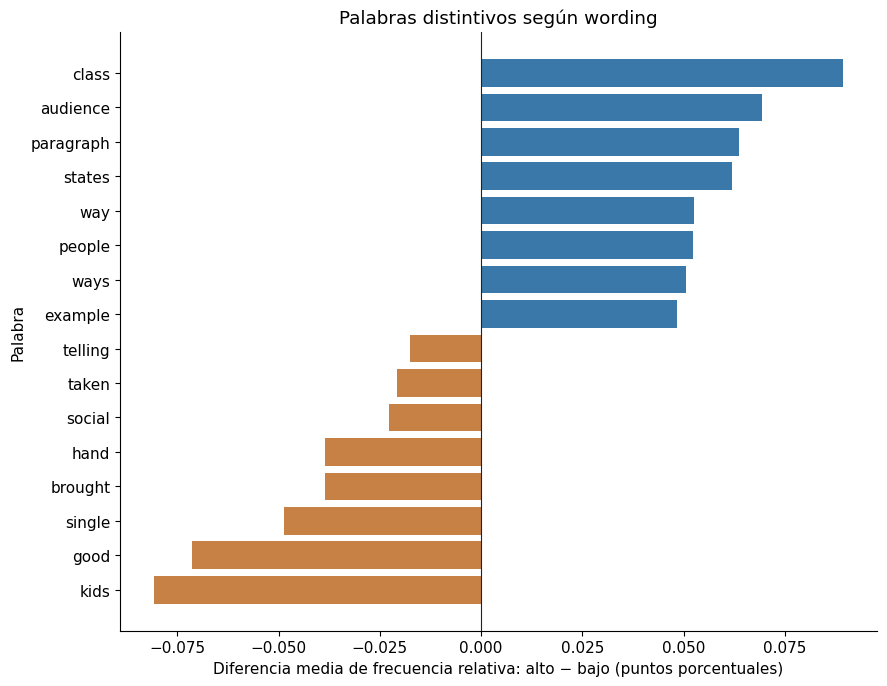

,objetivo,unidad,candidatos,presentes_en_2_o_mas_prompts
0,wording,bigramas,6304,2713


,ngram,prevalencia_baja,prevalencia_alta,frecuencia_relativa_baja,frecuencia_relativa_alta,diferencia_frecuencia_relativa,prompts_con_ngram,patron
0,like a,0.05194,0.07512,0.00122,0.00096,-0.00027,4,Mayor en nivel bajo
1,good or,0.01998,0.02903,0.00057,0.00038,-0.00018,3,Mayor en nivel bajo
2,good and,0.02254,0.03648,0.00057,0.00041,-0.00016,4,Mayor en nivel bajo
3,over time,0.00885,0.00686,0.00023,0.00008,-0.00015,3,Mayor en nivel bajo
4,i think,0.00853,0.00860,0.00025,0.00011,-0.00014,4,Mayor en nivel bajo
5,said it,0.00449,0.00183,0.00011,0.00002,-0.00010,3,Mayor en nivel bajo
6,the good,0.00917,0.01165,0.00024,0.00015,-0.00009,3,Mayor en nivel bajo
7,things and,0.00524,0.00544,0.00015,0.00006,-0.00009,4,Mayor en nivel bajo
8,the text,0.04440,0.11661,0.00090,0.00128,0.00038,4,Mayor en nivel alto
9,for example,0.00925,0.04710,0.00019,0.00050,0.00031,4,Mayor en nivel alto


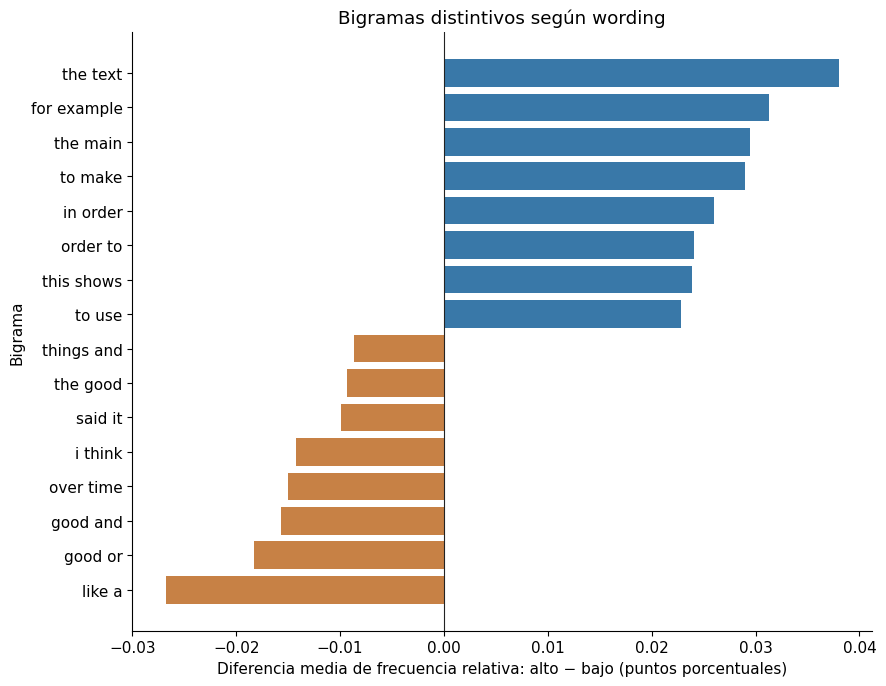

,prompt_id,objetivo,tercil_inferior,tercil_superior,n_bajo,n_medio,n_alto
0,39c16e,content,-0.5622,0.2057,686,641,730
1,3b9047,content,-0.5318,0.3764,673,655,681
2,814d6b,content,-0.3933,0.3764,403,316,384
3,ebad26,content,-0.5794,0.2970,666,656,674
4,39c16e,wording,-0.7151,0.3805,687,639,731
5,3b9047,wording,-0.5001,0.4134,671,668,670
6,814d6b,wording,0.1715,0.6271,370,324,409
7,ebad26,wording,-0.7962,0.0779,668,662,666


In [8]:
performance_results = {}
threshold_tables = []
for target in ['content', 'wording']:
    group_column = f'nivel_{target}'
    tokenized_summaries[group_column], thresholds = performance_groups_by_prompt(
        tokenized_summaries, target
    )
    threshold_tables.append(thresholds)
    for n, label, minimum in [(1, 'palabras', 20), (2, 'bigramas', 10)]:
        detail, aggregate = compare_extreme_group_prevalence(
            tokenized_summaries, 'tokens', group_column, n=n, min_document_count=minimum
        )
        robust = aggregate.loc[aggregate['prompts_con_ngram'] >= 2].copy()
        if n == 1:
            interpretable = robust.loc[~robust['ngram'].isin(ENGLISH_STOP_WORDS)].copy()
        else:
            interpretable = robust.loc[robust['ngram'].map(
                lambda value: any(token not in ENGLISH_STOP_WORDS for token in value.split())
            )].copy()
        positive = (interpretable.loc[interpretable['prompts_diferencia_positiva'] >= 3]
                    .nlargest(8, 'diferencia_frecuencia_relativa')
                    .assign(patron='Mayor en nivel alto'))
        negative = (interpretable.loc[interpretable['prompts_diferencia_negativa'] >= 3]
                    .nsmallest(8, 'diferencia_frecuencia_relativa')
                    .assign(patron='Mayor en nivel bajo'))
        selected = pd.concat([negative, positive], ignore_index=True).drop_duplicates('ngram')
        performance_results[(target, n)] = selected
        aggregate.to_csv(TABLES_DIR / f'05_{label}_{target}_prevalence_comparison.csv', index=False)
        display(pd.DataFrame({'objetivo': [target], 'unidad': [label],
                              'candidatos': [len(aggregate)],
                              'presentes_en_2_o_mas_prompts': [len(robust)]}))
        display(selected[['ngram', 'prevalencia_baja', 'prevalencia_alta',
                          'frecuencia_relativa_baja', 'frecuencia_relativa_alta',
                          'diferencia_frecuencia_relativa', 'prompts_con_ngram', 'patron']].round(5))
        plot_data = selected.sort_values('diferencia_frecuencia_relativa')
        colors = np.where(plot_data['diferencia_frecuencia_relativa'] >= 0, '#3978a8', '#c78145')
        fig, ax = plt.subplots(figsize=[9, 7])
        ax.barh(plot_data['ngram'], 100 * plot_data['diferencia_frecuencia_relativa'], color=colors)
        ax.axvline(0, color='#222222', linewidth=0.8)
        ax.set(title=f'{label.capitalize()} distintivos según {target}',
               xlabel='Diferencia media de frecuencia relativa: alto − bajo (puntos porcentuales)',
               ylabel=label[:-1].capitalize())
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / f'05_{label}_{target}_distinctive.png', dpi=150, bbox_inches='tight')
        plt.show()
thresholds_all = pd.concat(threshold_tables, ignore_index=True)
display(thresholds_all.round(4))
thresholds_all.to_csv(TABLES_DIR / '05_performance_group_thresholds.csv', index=False)

## 5. Coincidencia literal con el texto fuente

Esta medida calcula qué proporción de las palabras o bigramas únicos del resumen aparece literalmente en su `prompt_text`. Es una característica de comparación, no una propiedad original del resumen ni TF-IDF. Puede reflejar cobertura del tema, frases inevitables o copia literal; por sí sola no permite distinguir esas explicaciones.

In [9]:
prompt_token_map = tokenized_prompts.set_index('prompt_id')['tokens'].to_dict()
for n, label in [(1, 'palabras'), (2, 'bigramas')]:
    tokenized_summaries[f'{label}_prompt_overlap'] = tokenized_summaries.apply(
        lambda row: prompt_ngram_overlap(row['tokens'], prompt_token_map[row['prompt_id']], n=n), axis=1
    )
overlap_columns = ['palabras_prompt_overlap', 'bigramas_prompt_overlap']
overlap_description = tokenized_summaries[overlap_columns].describe().T
overlap_correlations = tokenized_summaries[overlap_columns + ['content', 'wording']].corr(
    method='spearman'
).loc[overlap_columns, ['content', 'wording']]
overlap_by_prompt = tokenized_summaries.groupby('prompt_id')[overlap_columns + ['content', 'wording']].corr(
    method='spearman'
).loc[(slice(None), overlap_columns), ['content', 'wording']]
display(overlap_description.round(4))
display(overlap_correlations.round(4))
display(overlap_by_prompt.round(4))
overlap_description.to_csv(TABLES_DIR / '05_prompt_overlap_descriptive.csv', index_label='variable')
overlap_correlations.to_csv(TABLES_DIR / '05_prompt_overlap_correlations.csv', index_label='variable')
overlap_by_prompt.to_csv(TABLES_DIR / '05_prompt_overlap_correlations_by_prompt.csv')

,count,mean,std,min,25%,50%,75%,max
palabras_prompt_overlap,7165.0,0.7076,0.1398,0.2821,0.6087,0.7045,0.8056,1.0
bigramas_prompt_overlap,7165.0,0.3533,0.2329,0.0000,0.1731,0.2903,0.4848,1.0


,content,wording
palabras_prompt_overlap,-0.1173,-0.4233
bigramas_prompt_overlap,0.0705,-0.2615


content  wording
prompt_id                                          
39c16e    palabras_prompt_overlap  -0.3209  -0.5135
          bigramas_prompt_overlap  -0.1015  -0.3340
3b9047    palabras_prompt_overlap   0.0691  -0.2450
          bigramas_prompt_overlap   0.2049  -0.1569
814d6b    palabras_prompt_overlap   0.0177  -0.1644
          bigramas_prompt_overlap   0.2632   0.0426
ebad26    palabras_prompt_overlap  -0.1851  -0.4784
          bigramas_prompt_overlap   0.0025  -0.3299

## 6. Índice de registro analítico frente a personal

La Sección 4 identificó qué palabras y bigramas distinguen los niveles alto y bajo de desempeño, pero solo como una comparación de promedios entre esos dos grupos extremos. Aquí se construye, para cada resumen, un índice continuo que cuenta cuántas veces aparecen esos mismos n-gramas distintivos, para ver si el patrón se sostiene como una relación gradual en las 7,165 observaciones, no solo en los extremos.

El índice reutiliza exactamente los n-gramas ya identificados como distintivos en la Sección 4: no es una validación independiente, sino una forma de comprobar si esa diferencia de grupo también aparece como gradiente continuo.

,ngram,n,rol
0,audience,1,analitico
1,class,1,analitico
2,example,1,analitico
3,finally,1,analitico
4,lastly,1,analitico
5,members,1,analitico
6,paragraph,1,analitico
7,people,1,analitico
8,shows,1,analitico
9,states,1,analitico


,count,mean,std,min,25%,50%,75%,max
analytic_score,7165.0,0.0249,0.0287,0.0000,0.0000,0.0185,0.0370,0.2500
personal_score,7165.0,0.0334,0.0327,0.0000,0.0081,0.0256,0.0500,0.2143
indice_registro,7165.0,-0.0086,0.0424,-0.2143,-0.0308,0.0000,0.0143,0.2449


,content,wording
analytic_score,0.2332,0.2467
personal_score,-0.0868,-0.0169
indice_registro,0.2236,0.1722


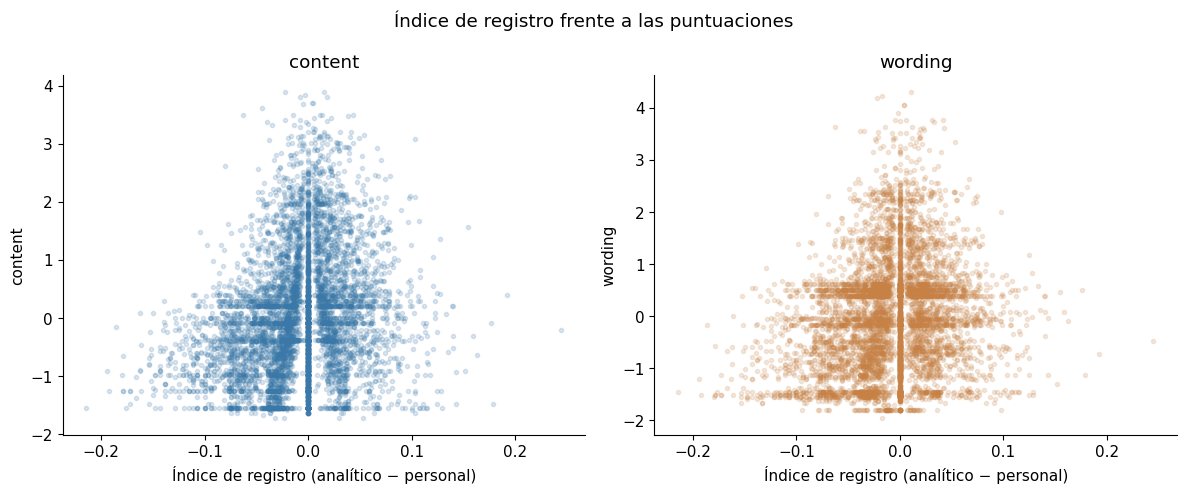

In [10]:
from src.ngrams import generate_ngrams

analytic_words, analytic_bigrams = set(), set()
personal_words, personal_bigrams = set(), set()
for (target, n), selected in performance_results.items():
    alto = set(selected.loc[selected['patron'] == 'Mayor en nivel alto', 'ngram'])
    bajo = set(selected.loc[selected['patron'] == 'Mayor en nivel bajo', 'ngram'])
    if n == 1:
        analytic_words |= alto
        personal_words |= bajo
    else:
        analytic_bigrams |= alto
        personal_bigrams |= bajo

ngram_lists = pd.DataFrame(
    [{'ngram': ngram, 'n': 1, 'rol': 'analitico'} for ngram in analytic_words]
    + [{'ngram': ngram, 'n': 2, 'rol': 'analitico'} for ngram in analytic_bigrams]
    + [{'ngram': ngram, 'n': 1, 'rol': 'personal'} for ngram in personal_words]
    + [{'ngram': ngram, 'n': 2, 'rol': 'personal'} for ngram in personal_bigrams]
)
display(ngram_lists.sort_values(['rol', 'n', 'ngram']).reset_index(drop=True))
ngram_lists.to_csv(TABLES_DIR / '05_register_index_ngram_lists.csv', index=False)

def count_ngram_hits(tokens, ngram_set, n):
    if not ngram_set:
        return 0
    return sum(1 for gram in generate_ngrams(tokens, n) if ' '.join(gram) in ngram_set)

analytic_count = tokenized_summaries['tokens'].map(
    lambda tokens: count_ngram_hits(tokens, analytic_words, 1) + count_ngram_hits(tokens, analytic_bigrams, 2)
)
personal_count = tokenized_summaries['tokens'].map(
    lambda tokens: count_ngram_hits(tokens, personal_words, 1) + count_ngram_hits(tokens, personal_bigrams, 2)
)
tokenized_summaries['analytic_score'] = analytic_count / tokenized_summaries['token_count']
tokenized_summaries['personal_score'] = personal_count / tokenized_summaries['token_count']
tokenized_summaries['indice_registro'] = (
    tokenized_summaries['analytic_score'] - tokenized_summaries['personal_score']
)

register_columns = ['analytic_score', 'personal_score', 'indice_registro']
register_description = tokenized_summaries[register_columns].describe().T
display(register_description.round(4))
register_description.to_csv(TABLES_DIR / '05_register_index_descriptive.csv', index_label='variable')

register_correlations = tokenized_summaries[register_columns + ['content', 'wording']].corr(
    method='spearman'
).loc[register_columns, ['content', 'wording']]
display(register_correlations.round(4))
register_correlations.to_csv(TABLES_DIR / '05_register_index_correlations.csv', index_label='variable')

fig, axes = plt.subplots(1, 2, figsize=[12, 5])
for ax, target, color in zip(axes, ['content', 'wording'], ['#3978a8', '#c78145']):
    ax.scatter(tokenized_summaries['indice_registro'], tokenized_summaries[target],
               s=9, alpha=0.18, color=color)
    ax.set(title=target, xlabel='Índice de registro (analítico − personal)', ylabel=target)
fig.suptitle('Índice de registro frente a las puntuaciones')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_register_index_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Interpretación y limitaciones de la contribución

- La frecuencia absoluta describe el corpus, pero no compara justamente textos de diferente longitud; por eso se acompaña de frecuencia relativa y prevalencia documental.
- Los patrones distintivos son asociaciones exploratorias entre grupos, no causas de las puntuaciones.
- El índice de registro analítico/personal (Sección 6) reutiliza los mismos n-gramas identificados como distintivos aquí; su correlación con `content` y `wording` no es una validación independiente, sino una comprobación de que el patrón de grupo también se sostiene como gradiente continuo.
- Formar terciles simplifica variables continuas y pierde información; se utiliza sólo para facilitar comparaciones descriptivas.
- El promedio de diferencias dentro de cada prompt reduce la dominancia de los temas, pero no elimina todas las diferencias contextuales.
- La ortografía no se corrige y variantes como `wouldnt` y `wouldn't` permanecen separadas.
- La coincidencia literal con el prompt no demuestra plagio ni calidad.
- No se construye Bag of Words ni se calcula TF-IDF, porque corresponden a otras contribuciones.

### Hallazgos verificados

Las palabras de mayor frecuencia global son principalmente funcionales: `the` aparece 43,484 veces y en 96.25 % de los resúmenes. La vista sin stopwords revela vocabulario fuertemente temático. Por ejemplo, `meat` es la palabra de contenido más frecuente, pero aparece en un solo prompt; por eso una lista global no puede interpretarse como vocabulario general de calidad.

El corpus contiene 95,262 bigramas distintos; 67.94 % aparece una sola vez. Para trigramas se observan 216,504 tipos y 80.94 % aparece una sola vez. Aunque algunos trigramas alcanzan una prevalencia superior al 10 %, la dispersión general es alta. Por eso se conservan sólo como descripción secundaria de frases frecuentes y no se usan para comparar niveles de desempeño.

Tras normalizar cada resumen por su número de n-gramas y exigir consistencia en al menos tres prompts, los niveles altos de `content` muestran con mayor frecuencia relativa expresiones de referencia y organización como `the text`, `it states`, `this shows` e `in paragraph`. En `wording`, el nivel alto presenta con mayor frecuencia relativa `for example`, `in order`, `order to` y `this shows`. Los niveles bajos muestran relativamente más expresiones como `i think` y `like a`. Son asociaciones pequeñas y exploratorias; no prueban que estas expresiones causen una puntuación determinada.

La mediana de coincidencia literal con el prompt es 70.45 % para palabras únicas y 29.03 % para bigramas únicos. Globalmente, la coincidencia se asocia más con `wording` que con `content`: Spearman es -0.423 para palabras y -0.262 para bigramas frente a `wording`. Sin embargo, la magnitud y hasta el signo cambian entre prompts, especialmente para `content`; por ello no debe reportarse una relación general sin ese control.

El índice de registro (Sección 6) confirma que el patrón de la Sección 4 se sostiene como relación continua, no solo entre los grupos extremos: `analytic_score` correlaciona con `content` (Spearman = 0.233) y con `wording` (0.247), más fuerte que cualquiera de los n-gramas individuales vistos por separado. `personal_score`, en cambio, correlaciona débil y casi nulo (-0.087 con `content`, -0.017 con `wording`). El índice combinado queda en 0.224 para `content` y 0.172 para `wording`. La señal viene sobre todo del lado "alto" (lenguaje de referencia y organización); el lado "personal" aporta mucho menos de lo que sugería la comparación de grupos extremos. Una palabra, `people`, salió distintiva en ambos sentidos según el objetivo, lo que recuerda que estas listas no forman una escala universal de "buen" o "mal" vocabulario, sino asociaciones específicas de cada puntuación.